# Tutorial 7: Population Questions — Dimensionality, Geometry, and Cross-Area Coupling

Every tutorial so far has used synthetic data with known ground truth.
Today we work with real neural recordings — and ask questions that synthetic
data cannot answer.

Neural populations encode information in high-dimensional patterns of activity,
but the *intrinsic* dimensionality of those patterns is often much lower than
the number of neurons. A population of 120 hippocampal neurons might encode
the animal's position in a 2-dimensional manifold — one dimension for location
along the track, one for running direction. A population of 100 visual cortex
neurons might encode the content of a natural movie in a higher-dimensional
space that is absent during spontaneous activity.

This tutorial uses `NeuralMI` to answer four related questions:

1. **Why can MI reveal dimensionality, and how many dimensions does the hippocampal population use?**
   (synthetic motivation with split-half sweep + `mode='dimensionality'` on real data)
2. **What does that low-dimensional representation look like geometrically?**
   (`mode='estimate'` with `return_embeddings=True`)
3. **Does the population carry position information above and beyond direction?**
   (`mode='conditional'` — controlling for a known variable)
4. **How does coupling between visual cortex and hippocampus depend on stimulus?**
   (four `mode='estimate'` calls on Allen Brain Observatory data)

We use two real datasets: a hippocampal recording from a mouse running on a
linear track, and population recordings from three brain regions (VISp, VISpm,
CA1) in the Allen Brain Observatory.

## Data

Both datasets should be placed in a `data/` subdirectory relative to this
notebook. The hippocampal data is in `hippocampus_achilles.npz`; the Allen
Brain Observatory data consists of six `.npy` files named
`spont_visp_20.npy`, `spont_vispm_20.npy`, `spont_ca1_20.npy`,
`nat_movie_visp_20.npy`, `nat_movie_vispm_20.npy`, and `nat_movie_ca1_20.npy`.

> **How to obtain the data files:** The data files for this tutorial are included
> in the `data/` subfolder of the tutorials directory in this repository. They can
> also be downloaded separately: the hippocampal dataset
> (`hippocampus_achilles.npz`) is the Achilles dataset from Grosmark & Buzsáki
> (2016), available from the CRCNS data sharing repository (crcns.org, dataset
> hc-11). The Allen Brain Observatory spike data (six `.npy` files) were extracted
> from the Allen SDK; see the Allen Brain Observatory documentation for access
> instructions.

Both datasets are **binned spike count matrices**: each entry is the number
of spikes fired by a neuron in a short time bin (0 for the hippocampal data;
20 ms bins for the Allen data). Because these are not raw spike timestamps,
we use `processor_type='continuous'` — the processor treats them as a
multichannel time series and applies windowing, regardless of the biological
meaning of the values.

**Shape convention reminder:** The continuous processor expects
`(n_timepoints, n_channels)`.  Our data files already load in this format
— `(n_timepoints, n_neurons)` — so **no transposition is needed**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For this tutorial, we'll use 10,000 time points only of all the datasets for faster runtime. You can increase this number for more accurate estimates at the cost of longer runtime.
n_timepoints = 10000

# --- Hippocampal data ---
data          = np.load('data/hippocampus_achilles.npz')
spikes_raw    = data['neural']    # (10178, 120) — timepoints × neurons
positions_raw = data['position']  # (10178, 2)  — timepoints × [position, direction]

# Split behavioral variables
position_continuous = positions_raw[:n_timepoints, 0:1]  # (10178, 1) — continuous position
direction_labels    = positions_raw[:n_timepoints, 1:2]  # (10178, 1) — 0=left, 1=right (integers)

# No transpose needed: data is already (n_timepoints, n_neurons) = (10178, 120)
# which is the format the continuous processor expects.
spikes = spikes_raw[:n_timepoints, :]  # (10178, 120)

print("--- Hippocampal Data ---")
print(f"Spikes:                   {spikes.shape}  (n_timepoints, n_neurons)")
print(f"Position (continuous):    {position_continuous.shape}  (n_timepoints, 1)")
print(f"Direction (left/right):   {direction_labels.shape}  (n_timepoints, 1)")
print(f"Unique direction labels:  {np.unique(direction_labels.astype(int))}")
print(f"Firing rate (mean):       "
      f"{spikes_raw.mean() / 20.0 * 1000:.2f} spikes/s  ")

--- Hippocampal Data ---
Spikes:                   (10000, 120)  (n_timepoints, n_neurons)
Position (continuous):    (10000, 1)  (n_timepoints, 1)
Direction (left/right):   (10000, 1)  (n_timepoints, 1)
Unique direction labels:  [0 1]
Firing rate (mean):       2.19 spikes/s  


In [3]:
# --- Allen Brain Observatory data ---
# All arrays load as (n_timepoints, n_neurons) — the format the continuous
# processor expects.  No transposition needed.
spont_visp  = np.load('data/spont_visp_20.npy')    # (90126, 100)
spont_vispm = np.load('data/spont_vispm_20.npy')   # (90126, 64)
spont_ca1   = np.load('data/spont_ca1_20.npy')     # (90126, 100)
nat_visp    = np.load('data/nat_movie_visp_20.npy')    # (60051, 100)
nat_vispm   = np.load('data/nat_movie_vispm_20.npy')   # (60051, 64)
nat_ca1     = np.load('data/nat_movie_ca1_20.npy')     # (60051, 100)

print("--- Allen Brain Observatory Data ---")
print(f"Spontaneous — VISp:  {spont_visp.shape}   (n_timepoints, n_neurons)")
print(f"Spontaneous — VISpm: {spont_vispm.shape}  (n_timepoints, n_neurons)")
print(f"Spontaneous — CA1:   {spont_ca1.shape}    (n_timepoints, n_neurons)")
print(f"Natural movie — VISp:  {nat_visp.shape}   (n_timepoints, n_neurons)")
print(f"Natural movie — VISpm: {nat_vispm.shape}  (n_timepoints, n_neurons)")
print(f"Natural movie — CA1:   {nat_ca1.shape}    (n_timepoints, n_neurons)")
print(f"\nBin size: 20 ms  |  "
      f"Spontaneous duration: {spont_visp.shape[0] * 0.02 / 60:.1f} min  |  "
      f"Natural movie duration: {nat_visp.shape[0] * 0.02 / 60:.1f} min")

# Chunk to smaller sizes for faster runtime in this tutorial. You can increase these numbers for more accurate estimates at the cost of longer runtime.
spont_visp = spont_visp[:n_timepoints, :]
spont_vispm = spont_vispm[:n_timepoints, :]
spont_ca1 = spont_ca1[:n_timepoints, :]
nat_visp = nat_visp[:n_timepoints, :]
nat_vispm = nat_vispm[:n_timepoints, :]
nat_ca1 = nat_ca1[:n_timepoints, :]

# Print sizes after chunking
print("\nAfter chunking to 10,000 time points:")
print(f"Spontaneous — VISp:  {spont_visp.shape}   (n_timepoints, n_neurons)")
print(f"Spontaneous — VISpm: {spont_vispm.shape}  (n_timepoints, n_neurons)")
print(f"Spontaneous — CA1:   {spont_ca1.shape}    (n_timepoints, n_neurons)")
print(f"Natural movie — VISp:  {nat_visp.shape}   (n_timepoints, n_neurons)")
print(f"Natural movie — VISpm: {nat_vispm.shape}  (n_timepoints, n_neurons)")
print(f"Natural movie — CA1:   {nat_ca1.shape}    (n_timepoints, n_neurons)")

--- Allen Brain Observatory Data ---
Spontaneous — VISp:  (90126, 100)   (n_timepoints, n_neurons)
Spontaneous — VISpm: (90126, 64)  (n_timepoints, n_neurons)
Spontaneous — CA1:   (90126, 100)    (n_timepoints, n_neurons)
Natural movie — VISp:  (60051, 100)   (n_timepoints, n_neurons)
Natural movie — VISpm: (60051, 64)  (n_timepoints, n_neurons)
Natural movie — CA1:   (60051, 100)    (n_timepoints, n_neurons)

Bin size: 20 ms  |  Spontaneous duration: 30.0 min  |  Natural movie duration: 20.0 min

After chunking to 10,000 time points:
Spontaneous — VISp:  (10000, 100)   (n_timepoints, n_neurons)
Spontaneous — VISpm: (10000, 64)  (n_timepoints, n_neurons)
Spontaneous — CA1:   (10000, 100)    (n_timepoints, n_neurons)
Natural movie — VISp:  (10000, 100)   (n_timepoints, n_neurons)
Natural movie — VISpm: (10000, 64)  (n_timepoints, n_neurons)
Natural movie — CA1:   (10000, 100)    (n_timepoints, n_neurons)


## Act 1: Why Can MI Reveal Dimensionality?

Neural populations can encode many variables simultaneously, but the
*intrinsic* dimensionality of their activity is often much lower than the
number of neurons.  A population of 120 hippocampal neurons might encode
position in a 2-dimensional manifold — one axis for location, one for
direction. Alternatively, when we consider the *interaction* dimensionality
between two variables, this is effectively their communication subspace, and
quantifying it is important.

**The sweep approach (interaction dimensionality).**  Pass
X and Y and sweep `embedding_dim` from 1 upward.  Where MI plateaus = D.
This works for any two-variable setup: you can find
the dimensionality of the *coupling* between two brain regions.

In such case, MI rises sharply from `embedding_dim=1` to `embedding_dim=D`, then
plateaus — the network has captured all $D$ shared latent dimensions and
there is nothing more to learn.  Beyond $D$, extra embedding capacity is
wasted on noise, and MI stays flat.

**The split-half trick (intrinsic dimensionality).**  Split the population randomly into two non-overlapping
halves.  Each half observes the same low-dimensional latent activity, but
through different neurons.  The mutual information between the two halves
$I(\text{half}_1;\, \text{half}_2)$ therefore equals the information in the
shared representation — and that information saturates at the true number of
shared latent dimensions $D$.


**Train once (PR approach)**
The sweep approach works, but it requires training one model per
`embedding_dim` value.  A faster alternative: train **once** at a large
`embedding_dim` (default 64, enough to capture any realistic dimensionality),
extract the learned embeddings $z_X$ and $z_Y$, and compute the
**participation ratio** of their cross-covariance matrix.

$$PR = \frac{(\sum_i s_i)^2}{\sum_i s_i^2}$$

where $s_i$ are the singular values of the cross-covariance matrix
(after whitening per dimension).  PR measures how many singular values
contribute meaningfully: if all $D$ dimensions share equal signal,
$PR = D$; if only one dimension dominates, $PR \approx 1$.

`mode='dimensionality'` implements exactly this: either take $X$ and $Y$ and
compute their interaction dimensionality, or take $X$ and split channels randomly
into two halves (`n_splits` times for stability), train the hybrid critic
at large `embedding_dim`, extract embeddings, and return the mean PR across
splits alongside the MI estimate.


**A note on the critic type.**  The default separable critic compresses X and
Y into embeddings *independently* before comparing them.  This forces the
network to use at least one extra embedding dimension to represent the
"scale" of the joint distribution, inflating the saturation point by 1 or
more.  The **hybrid critic** avoids this inflation by sharing some computation
between the two branches.  It is therefore the correct choice for
dimensionality analysis, and `mode='dimensionality'` uses it by default.
We cover critic architecture in detail in Tutorial 8.

### Real Data: How Many Dimensions Does the Hippocampal Population Use?

A mouse running back and forth on a linear track inhabits a 2-dimensional
behavioral space: position along the track (continuous) and running direction
(binary, left or right).  If the hippocampal population faithfully encodes
this behavior, the PR of the split-half MI should converge to approximately 2.

In [4]:
model_dim = nmi.Model(embedding_dim=64)   # large enough to capture all dimensions; PR tells us the effective count (also the default)
training_dim = nmi.Training(n_epochs=100, patience=20, learning_rate=1e-4)

window_size_hip = 20  # 20 timepoints per window
step_size_hip   = 1  # High overlap → more samples for better estimation

print("Running dimensionality analysis on hippocampal population...")

dim_results = nmi.run(
    spikes,
    mode='dimensionality',
    processing=nmi.Processing(x='continuous', x_params={'window_size': window_size_hip, 'step_size': step_size_hip}),   # binned spikes → continuous processor
    split=nmi.Split(mode='blocked'),             # CORRECT: continuous recording
    model=model_dim, training=training_dim,
    dimensionality=nmi.Dimensionality(n_splits=5),   # average over 5 random channel splits
    n_workers=4,
)

Running dimensionality analysis on hippocampal population...


Dimensionality Splits:   0%|          | 0/5 [00:00<?, ?it/s]2026-04-21 22:42:22 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...
2026-04-21 22:42:22 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...
2026-04-21 22:42:22 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...
2026-04-21 22:42:22 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...
Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]2026-04-21 22:42:22 - neural_mi - INFO - Created PairedDataset
2026-04-21 22:42:22 - neural_mi - INFO - Created PairedDataset
2026-04-21 22:42:22 - neural_mi - INFO - Created PairedDataset
2026-04-21 22:42:22 - neural_mi - INFO - Created PairedDataset

Run 9f8a6a24-8d2d-45ac-994b-87666c24d40d_c0:   0%|          | 0/100 [00:00<?, ?it/s]
Run 52431fc5-97fe-4c5f-aac2-e39950a00627_c0 | MI: 0.004:   0%|          | 0/100 [00:04<?, ?it/s]
Run 52431fc5-97fe-4c5f-aac2-e39950a00627_c0 | MI: 0.004: 

In [5]:
df_dim  = dim_results.dataframe
pr_mean = df_dim['pr_singular_mean'].iloc[0]
pr_std  = df_dim['pr_singular_std'].iloc[0]
mi_mean = df_dim['mi_mean'].iloc[0]
mi_std  = df_dim['mi_std'].iloc[0]

print(f"MI between population halves: {mi_mean:.3f} ± {mi_std:.3f} bits")
print(f"Participation ratio:          {pr_mean:.2f} ± {pr_std:.2f}")
print(f"\nInterpretation: the hippocampal population uses "
      f"≈{pr_mean:.1f} effective dimensions to encode its activity.")

MI between population halves: 4.183 ± 0.395 bits
Participation ratio:          1.85 ± 0.16

Interpretation: the hippocampal population uses ≈1.9 effective dimensions to encode its activity.


The participation ratio should converge to approximately 2 — consistent with
the two-dimensional behavioral space the animal inhabits (position along the
track and running direction).

This result was obtained without any knowledge of the behavioral variables —
the analysis used only the spike data itself, split into random halves.
The fact that it recovers the dimensionality of the known behavioral space is
a validation of both the method and the assumption that hippocampal activity
faithfully encodes the animal's spatial state.

## Act 2: What Does the Low-Dimensional Representation Look Like?

Knowing that the representation is approximately 2-dimensional is the first
step. The second is to ask: what *is* that 2D representation? What does the
learned embedding space look like, and does it correspond to anything
interpretable?

We train a fresh model with `embedding_dim=2` — forcing the network to compress
all information into a 2D bottleneck — and extract the learned embeddings using
`return_embeddings=True`. Each window of spike data maps to a single point in
this 2D space.

We then colour those points by the two behavioral variables: continuous position
along the track, and running direction (left vs. right). If the network has
learned a meaningful representation, the geometry of the embedding should
reflect the geometry of the animal's behavior.

We use a smaller window size (`window_size=10`) for this analysis to generate
more embedding points and reveal finer structure in the manifold.

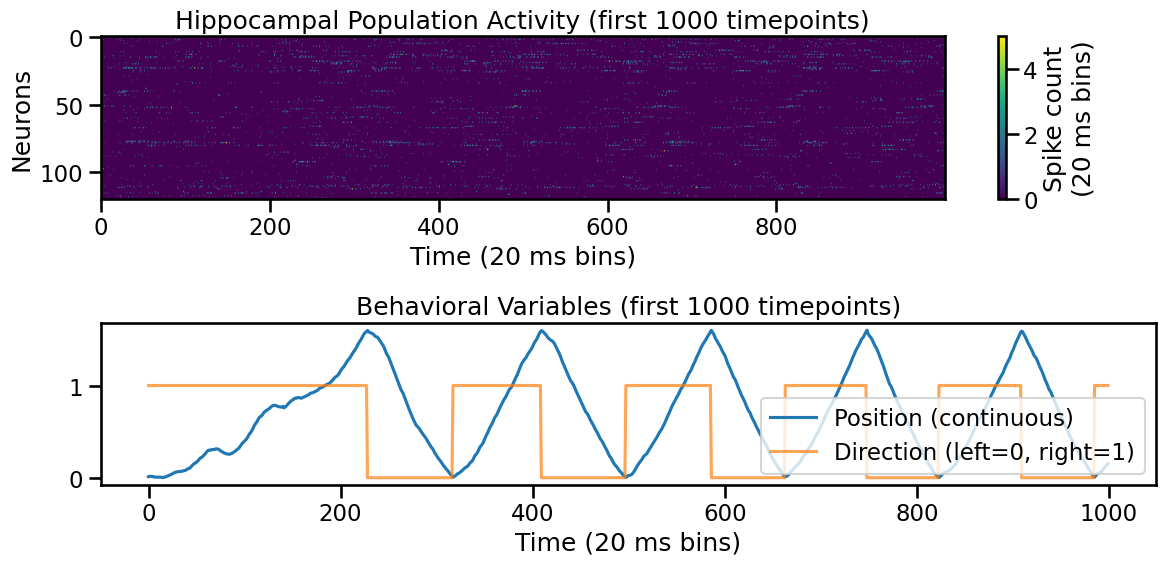

In [6]:
# Visualize the raw data for the first 1000 timepoints to get a sense of the structure
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.imshow(spikes[:1000].T, aspect='auto', cmap='viridis')
plt.colorbar(label='Spike count\n(20 ms bins)')
plt.title('Hippocampal Population Activity (first 1000 timepoints)')
plt.xlabel('Time (20 ms bins)')
plt.ylabel('Neurons')
plt.subplot(2, 1, 2)
plt.plot(position_continuous[:1000], label='Position (continuous)')
plt.plot(direction_labels[:1000], label='Direction (left=0, right=1)', alpha=0.7)
plt.title('Behavioral Variables (first 1000 timepoints)')
plt.xlabel('Time (20 ms bins)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
model_embed = nmi.Model(hidden_dim=256, embedding_dim=2, n_layers=3)   # 2D bottleneck — matches estimated dimensionality
training_embed = nmi.Training(n_epochs=150, patience=30, learning_rate=5e-5)

window_size_embed = 20
step_size_embed = 1   # 50% overlap: denser sampling than non-overlap at ws=20

print("Training with embedding_dim=2 and return_embeddings=True...")
embed_results = nmi.run(
    spikes,
    mode='dimensionality',
    processing=nmi.Processing(x='continuous', x_params={'window_size': window_size_embed, 'step_size': step_size_embed}),   # binned spikes → continuous processor
    split=nmi.Split(mode='blocked'),             # CORRECT: continuous recording
    model=model_embed, training=training_embed,
    output=nmi.Output(return_embeddings=True),
    dimensionality=nmi.Dimensionality(n_splits=1),   # single split sufficient for visualisation
    n_workers=1,      # single split, no parallelism needed
    seed=42
)

# Embeddings are stored in details['raw_results'] as columns 'embeddings_x' and 'embeddings_y'
# They are extracted for all processed windows.
embeddings = embed_results.details.get('embeddings', None)
embedding_window_starts = None
if embeddings is None:
    raw_df = embed_results.details.get('raw_results', None)
    if raw_df is not None and 'embeddings_x' in raw_df.columns:
        embeddings = raw_df['embeddings_x'].iloc[0]  # X-half embeddings (n_windows, 2)
        if 'embedding_window_starts' in raw_df.columns:
            embedding_window_starts = raw_df['embedding_window_starts'].iloc[0]
        elif 'embedding_indices' in raw_df.columns:
            embedding_window_starts = raw_df['embedding_indices'].iloc[0] * step_size_embed

if embeddings is None:
    print("WARNING: 'embeddings' key not found in results.details.")
    print("Available keys:", list(embed_results.details.keys()))
else:
    print(f"Embeddings shape: {embeddings.shape}  (n_windows, embedding_dim)")

Training with embedding_dim=2 and return_embeddings=True...


Sequential Sweep Progress: 100%|██████████| 1/1 [04:22<00:00, 262.88s/it]

Available keys: ['raw_results', 'embeddings_x', 'embeddings_y']


In [8]:
# The spike data was windowed with a chosen window_size and step_size.
# We align behavioral labels by taking the mean (for position) or
# mode (for direction) within each window.

n_windows = embeddings.shape[0] if embeddings is not None else (
    spikes.shape[0] // window_size_embed
)
if embedding_window_starts is None:
    embedding_window_starts = np.arange(n_windows) * step_size_embed
embedding_window_starts = np.asarray(embedding_window_starts).astype(int)

# Align position: mean within each window
position_windowed = np.array([
    position_continuous[s:min(s + window_size_embed, len(position_continuous)), 0].mean()
    for s in embedding_window_starts
])

# Align direction: mode within each window (0=left, 1=right)
direction_windowed = np.array([
    int(np.round(
        direction_labels[s:min(s + window_size_embed, len(direction_labels)), 0].mean()
    ))
    for s in embedding_window_starts
])

print(f"Windowed position shape:  {position_windowed.shape}")
print(f"Windowed direction shape: {direction_windowed.shape}")
print(f"Direction values present: {np.unique(direction_windowed)}")
print(f"window_size={window_size_embed}, step_size={step_size_embed}, "
      f"n_embedding_windows={len(embedding_window_starts)}")

Windowed position shape:  (500,)
Windowed direction shape: (500,)
Direction values present: [0 1]
window_size=20, step_size=1, n_embedding_windows=500


In [9]:
if embeddings is None:
    print("WARNING: Embeddings not found — skipping scatter plots.")
    print("The embedding visualisation requires return_embeddings=True to store "
          "the learned 2D representation in results.details.")
else:
    fig, (ax_pos, ax_dir) = plt.subplots(1, 2, figsize=(14, 6))

    # Left panel: coloured by continuous position
    sc = ax_pos.scatter(embeddings[:, 0], embeddings[:, 1],
                        c=position_windowed, cmap='viridis', s=10, alpha=0.7)
    plt.colorbar(sc, ax=ax_pos, label="Position along track")
    ax_pos.set_title("2D Embedding — coloured by position")
    ax_pos.set_xlabel("Embedding dim 1")
    ax_pos.set_ylabel("Embedding dim 2")

    # Right panel: coloured by direction (0=left, 1=right)
    dir_colors = np.where(direction_windowed == 0, 0, 1).astype(float)
    # make a color map that's steel blue for 0 and dark orange for 1
    cmap = cm.colors.ListedColormap(['steelblue', 'darkorange'])
    sc2 = ax_dir.scatter(embeddings[:, 0], embeddings[:, 1],
                         c=dir_colors, cmap=cmap, s=10, alpha=0.7, vmin=0, vmax=1)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=8, label='Left run'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange',
               markersize=8, label='Right run'),
    ]
    ax_dir.legend(handles=legend_elements)
    ax_dir.set_title("2D Embedding — coloured by direction")
    ax_dir.set_xlabel("Embedding dim 1")
    ax_dir.set_ylabel("Embedding dim 2")

    plt.tight_layout()
    plt.show()

The embedding visualisation requires return_embeddings=True to store the learned 2D representation in results.details.


The two panels reveal the geometry of the hippocampal representation.
When coloured by position, the embedding should form a continuous trajectory
— points close in embedding space correspond to similar positions on the track.
When coloured by direction, the two runs (left and right) should separate
into distinct clusters or manifolds within the same 2D space.

This geometry is exactly what you would expect from a place cell population
with directional tuning: the same physical location on the track has a
different neural representation depending on whether the animal is running
left or right. The 2D embedding captures both of these facts simultaneously —
one axis roughly encodes position, the other encodes direction.

Crucially, the network learned this representation without being told about
position or direction. It discovered the low-dimensional structure by
maximising mutual information between two random halves of the neural
population. This is what MI-based dimensionality analysis reveals:
not just a number, but the geometry of the code.

## Act 3: Position Information Above and Beyond Direction

The embedding suggests that the hippocampal population encodes both position
and direction. But how much of the position information is genuinely
*position-specific*, and how much is simply a consequence of knowing which
direction the animal is running?

This is exactly the question that **conditional mutual information** answers:

$$I(\text{spikes};\, \text{position} \mid \text{direction}) =
  I(\text{spikes},\, \text{direction};\, \text{position}) -
  I(\text{direction};\, \text{position})$$

In words: how much information do the spikes carry about position, above and
beyond what direction alone tells you about position?

We use `mode='conditional'` with:
- X = spikes (the neural signal)
- Y = continuous position (the variable we want to predict)
- Z = running direction (the variable we are conditioning on)

The direction variable is passed through the **categorical processor** —
connecting back to Tutorial 2. Each integer label (0 or 1) is one-hot
encoded within each window, giving the network a proper representation of
the discrete state.

In [10]:
training_cmi = nmi.Training(n_epochs=100, patience=20, learning_rate=1e-4)

window_size_cmi = 20
step_size_cmi = 1

print("Running conditional MI: I(spikes ; position | direction)...")
print("This computes two MI estimates internally and returns their difference.\n")

cmi_results = nmi.run(
    spikes, position_continuous,
    mode='conditional',
    conditional=nmi.Conditional(
        z_data=direction_labels,
        # Z: direction labels — same window_size as X/Y
        z_processor_type='continuous',
        z_processor_params={'window_size': window_size_cmi, 'step_size': step_size_cmi},
    ),
    # X: spike matrix (n_timepoints, n_neurons); Y: continuous position — both windowed
    processing=nmi.Processing(
        x='continuous', x_params={'window_size': window_size_cmi, 'step_size': step_size_cmi},
        y='continuous', y_params={'window_size': window_size_cmi, 'step_size': step_size_cmi},
    ),
    split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
    training=training_cmi,
    n_workers=1,
)

cmi         = cmi_results.mi_estimate
mi_spikes_z = cmi_results.details['mi_z_y']    # I(direction ; position)
mi_xz_pos   = cmi_results.details['mi_xz_y']   # I(spikes, direction ; position)

print(f"--- Conditional MI Results ---")
print(f"I(direction ; position):              {mi_spikes_z:.3f} bits")
print(f"I(spikes, direction ; position):      {mi_xz_pos:.3f} bits")
print(f"I(spikes ; position | direction):     {cmi:.3f} bits")
print(f"\nInterpretation: the spike population carries {cmi:.3f} bits about "
      f"position that cannot be explained by direction alone.")

Running conditional MI: I(spikes ; position | direction)...
This computes two MI estimates internally and returns their difference.



Sequential Sweep Progress: 100%|██████████| 1/1 [00:40<00:00, 40.80s/it]

--- Conditional MI Results ---
I(direction ; position):              1.487 bits
I(spikes, direction ; position):      4.474 bits
I(spikes ; position | direction):     2.987 bits

Interpretation: the spike population carries 2.987 bits about position that cannot be explained by direction alone.


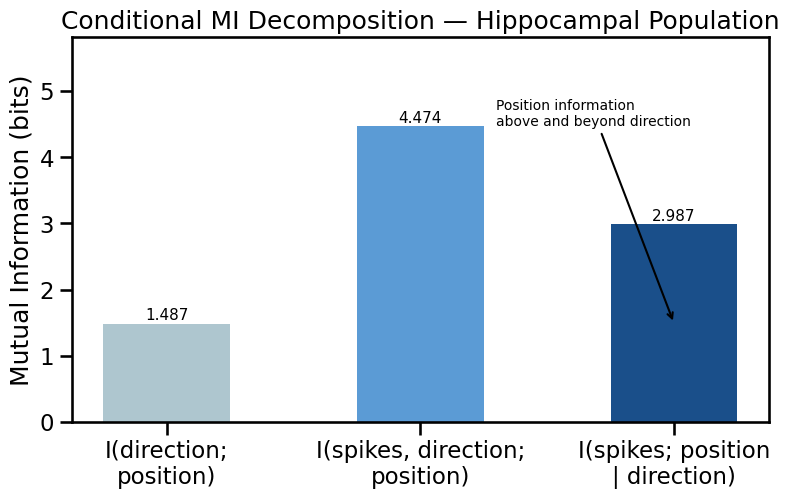

In [11]:
labels = [
    'I(direction;\nposition)',
    'I(spikes, direction;\nposition)',
    'I(spikes; position\n| direction)'
]
values = [mi_spikes_z, mi_xz_pos, cmi]
colors = ['#aec6cf', '#5b9bd5', '#1a4f8a']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.set_ylabel("Mutual Information (bits)")
ax.set_title("Conditional MI Decomposition — Hippocampal Population")
ax.set_ylim(bottom=0)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)

# Annotate the conditional MI bar
ax.annotate("Position information\nabove and beyond direction",
            xy=(2, cmi / 2),
            xytext=(1.3, cmi * 1.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)
plt.ylim(0, max(values) * 1.3)
plt.show()

The bar chart decomposes the position information into two parts. The first
bar ($I(\text{direction}; \text{position})$) shows how much position
information is already contained in knowing the running direction alone —
some position information is implicit in direction because the animal tends
to be at different locations depending on which way it is heading.

The second bar ($I(\text{spikes}, \text{direction}; \text{position})$) shows
the total position information when both spikes and direction are available.

The third bar — the conditional MI — is the difference: the unique
contribution of the spikes above and beyond direction. If this value is
substantial, the hippocampal population carries genuine position-specific
information that cannot be reduced to a simple directional signal. This is
consistent with the known properties of place cells: each place cell fires
in a specific location regardless of direction, providing a position code
that is richer than direction alone.

## Act 4: Stimulus-Dependent Cross-Area Coupling in the Allen Brain Observatory

Our final question moves from single-population geometry to inter-area
communication. The Allen Brain Observatory recorded simultaneously from
three brain regions in awake mice: primary visual cortex (VISp),
posteromedial visual cortex (VISpm), and hippocampus (CA1). Recordings
were made during two conditions: **spontaneous activity** (no visual stimulus)
and **natural movie viewing**.

We estimate MI between population pairs across both conditions:

- **VISp ↔ VISpm**: two hierarchically adjacent visual areas. We expect high
  MI in both conditions, because these areas are strongly anatomically
  connected and share visual drive.
- **VISp ↔ CA1**: visual cortex and hippocampus. We expect MI to be low
  during spontaneous activity (no shared drive) and high during natural
  movie viewing (the movie provides a common structure that both areas
  respond to, and hippocampus is known to encode temporal context).

Each call passes the full population matrix of one region as X and another
region as Y, estimating the total MI between the two populations.

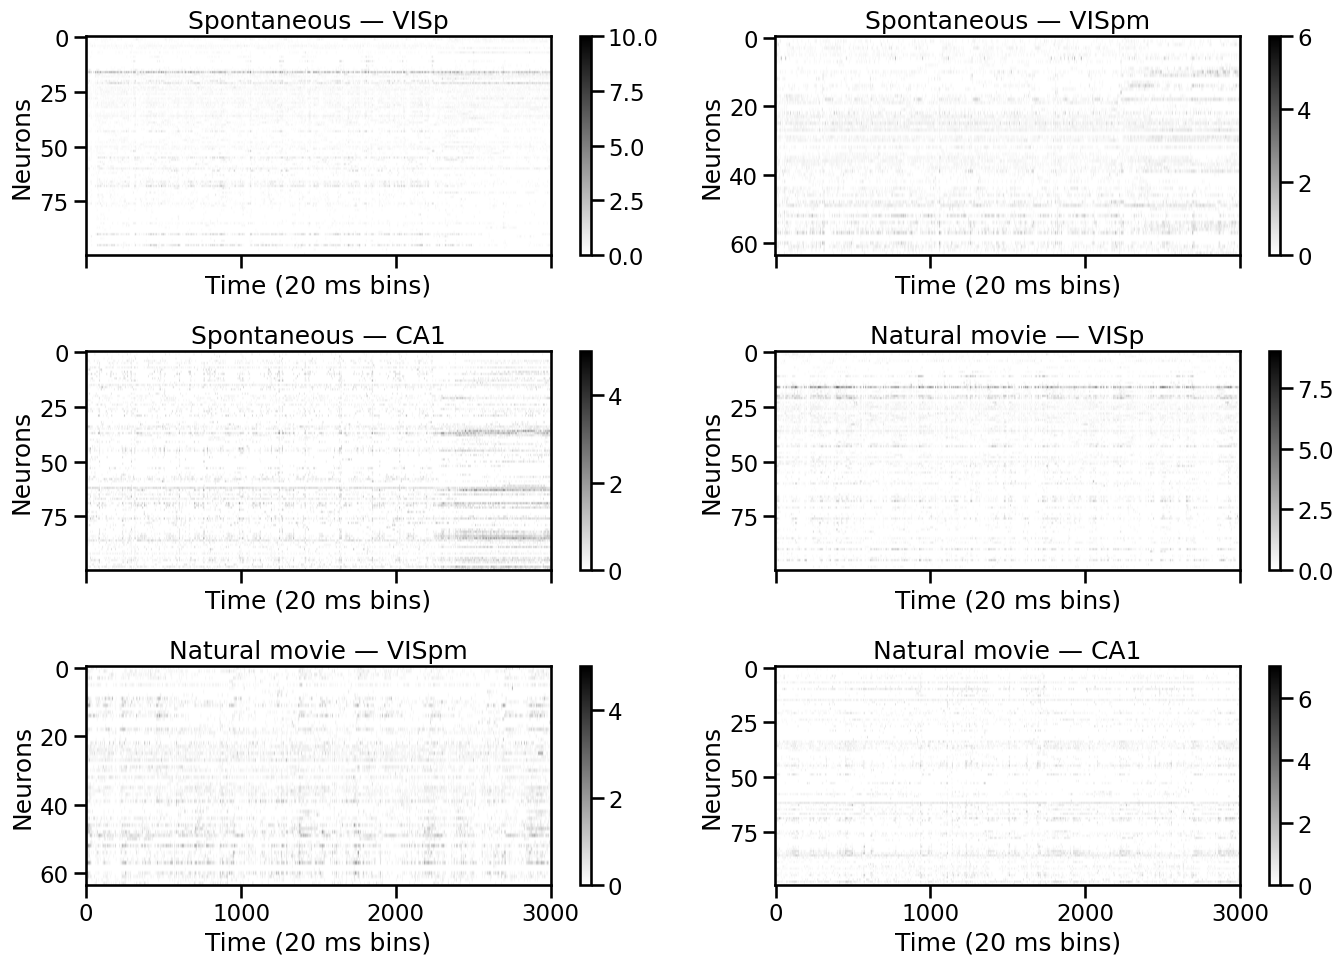

In [12]:
# Visualize the raw data for the Allen Brain Observatory conditions to get a sense of it
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
datasets = [
    (spont_visp, 'Spontaneous — VISp'),
    (spont_vispm, 'Spontaneous — VISpm'),
    (spont_ca1, 'Spontaneous — CA1'),
    (nat_visp, 'Natural movie — VISp'),
    (nat_vispm, 'Natural movie — VISpm'),
    (nat_ca1, 'Natural movie — CA1'),
]
for ax, (data, title) in zip(axes.flatten(), datasets):
    im = ax.imshow(data[:3001].T, aspect='auto', cmap='gray_r')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("Time (20 ms bins)")
    ax.set_ylabel("Neurons")
plt.tight_layout()
plt.show()

In [13]:
training_allen = nmi.Training(n_epochs=100, patience=20)

window_size_allen = 20  # 20 bins × 20 ms = 400 ms windows
step_size_allen = 1     # overlapping windows for higher effective sample count

conditions = {
    'VISp ↔ VISpm\n(spont)':  (spont_visp,  spont_vispm),
    'VISp ↔ VISpm\n(movie)':  (nat_visp,    nat_vispm),
    'VISp ↔ CA1\n(spont)':    (spont_visp,  spont_ca1),
    'VISp ↔ CA1\n(movie)':    (nat_visp,    nat_ca1),
}

allen_results = {}
allen_stds = {}

for label, (x_pop, y_pop) in conditions.items():
    print(f"Estimating MI: {label}...")
    estimates = []
    r = nmi.run(
        x_pop, y_pop,
        mode='sweep',
        processing=nmi.Processing(x='continuous', x_params={'window_size': window_size_allen, 'step_size': step_size_allen},   # binned spikes → continuous processor
                                  y='continuous', y_params={'window_size': window_size_allen, 'step_size': step_size_allen}),
        split=nmi.Split(mode='blocked'),    # CORRECT: continuous recording
        training=training_allen,
        sweep_grid={'run_id': range(3)},  # 3 runs with different random seeds for variability estimate
        n_workers=1,
    )
    estimates.append(r.dataframe[['train_mi']])

    allen_results[label] = float(np.mean(estimates))
    allen_stds[label] = float(np.std(estimates))
    print(f"  MI = {allen_results[label]:.3f} ± {allen_stds[label]:.3f} bits  ")

Estimating MI: VISp ↔ VISpm
(spont)...


Sequential Sweep Progress: 100%|██████████| 3/3 [00:32<00:00, 10.85s/it]


  MI = 3.104 ± 0.070 bits  
Estimating MI: VISp ↔ VISpm
(movie)...


Sequential Sweep Progress: 100%|██████████| 3/3 [00:32<00:00, 10.72s/it]


  MI = 5.493 ± 0.177 bits  
Estimating MI: VISp ↔ CA1
(spont)...


Sequential Sweep Progress: 100%|██████████| 3/3 [00:32<00:00, 10.97s/it]


  MI = 2.845 ± 0.336 bits  
Estimating MI: VISp ↔ CA1
(movie)...


Sequential Sweep Progress: 100%|██████████| 3/3 [00:31<00:00, 10.40s/it]

  MI = 2.525 ± 0.358 bits  


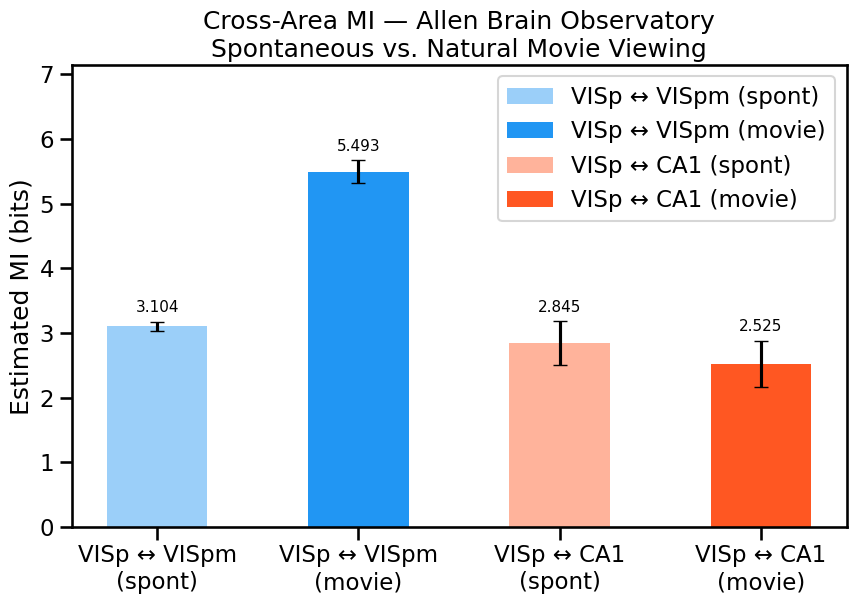

In [14]:
labels_allen = list(allen_results.keys())
values_allen = list(allen_results.values())
errors_allen = [allen_stds[k] for k in labels_allen]

# Group by pair type for visual clarity
pair_colors = {
    'VISp ↔ VISpm': '#2196F3',   # blue for visual-visual pair
    'VISp ↔ CA1':   '#FF5722',   # orange for visual-hippocampal pair
}

colors_allen = []
for lbl in labels_allen:
    if 'VISpm' in lbl:
        colors_allen.append(pair_colors['VISp ↔ VISpm'])
    else:
        colors_allen.append(pair_colors['VISp ↔ CA1'])

# Use lighter shades for spontaneous, full color for movie
alphas = [0.45, 1.0, 0.45, 1.0]  # spont lighter, movie full

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels_allen, values_allen, yerr=errors_allen, capsize=5,
              color=colors_allen, alpha=1.0, width=0.5)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

ax.set_ylabel("Estimated MI (bits)")
ax.set_title("Cross-Area MI — Allen Brain Observatory\n"
             "Spontaneous vs. Natural Movie Viewing")
ax.set_ylim(bottom=0)

# Annotate bar values
for bar, val in zip(bars, values_allen):
    bar_height = bar.get_height()
    error_height = errors_allen[bars.index(bar)]
    ax.text(bar.get_x() + bar.get_width() / 2, 
            bar_height + error_height + 0.1,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)
            
# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', alpha=0.45, label='VISp ↔ VISpm (spont)'),
    Patch(facecolor='#2196F3', alpha=1.0,  label='VISp ↔ VISpm (movie)'),
    Patch(facecolor='#FF5722', alpha=0.45, label='VISp ↔ CA1 (spont)'),
    Patch(facecolor='#FF5722', alpha=1.0,  label='VISp ↔ CA1 (movie)'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.ylim(0, max(values_allen) * 1.3)
plt.show()

The plot tells a clear and biologically rich story. First, notice that the MI during spontaneous activity is substantial for both pairs. "Spontaneous" activity in awake mice is not random noise; it is heavily modulated by global behavioral states like arousal, pupil dilation, and locomotion. The visual cortex and the hippocampus are both simultaneously reacting to these internal state changes, yielding a baseline shared variance even when the screen is blank.

The VISp ↔ VISpm MI (blue bars) shows a massive additive sensory response. While they share a strong baseline during spontaneous activity due to anatomical connectivity and arousal, this jumps by roughly 2 bits during the natural movie. Both areas are hierarchically adjacent visual regions; when the movie plays, they are hit with a massive, structured feedforward sensory drive, causing their shared variance to explode.

The VISp ↔ CA1 MI (orange bars), however, shows a much more subtle condition dependence, rising only modestly from its spontaneous baseline. This makes perfect sense: CA1 is a spatial and memory hub, not a primary visual processing area. It isn't blindly tracking the pixel-by-pixel changes of the movie. Instead, the hippocampus tracks the episodic or temporal context of the movie, sharing just enough higher-order structure with the visual cortex to encode the passage of events.

This dissociation — a massive sensory-evoked additive signal for adjacent visual areas, versus a subtle, context-driven additive signal across systems — highlights the power of population-level MI. It seamlessly captures both the brain-wide behavioral states and the task-specific information routing that would be completely invisible to single-unit analyses.

## 5. Key Takeaways

- **`mode='dimensionality'`** estimates intrinsic dimensionality from the
  participation ratio of the learned embedding. It requires only the neural
  data itself — no behavioral labels needed. Run with `n_splits > 1` for
  stable estimates.

- **`return_embeddings=True`** gives access to the learned low-dimensional
  representation. Train at the estimated dimensionality and colour the
  embedding by behavioral variables to reveal the geometry of the neural code.

- **`mode='conditional'`** answers "how much information does X carry about Y,
  above and beyond Z?" Pass the conditioning variable Z via `z_data` with its
  own processor type. Use `processor_type='categorical'` for discrete variables
  like behavioral states or trial labels.

- **Binned spike matrices use `processor_type='continuous'`**, not `'spike'`.
  The processor treats the matrix as a multichannel time series regardless of
  the biological meaning of the values. Transpose to `(n_neurons, n_timepoints)`
  before passing.

- **Population-level MI captures structure invisible to single-unit analyses.**
  The cross-area MI between VISp and CA1 is a property of the joint population
  activity — it cannot be recovered by analysing one neuron at a time.

## Common Mistakes

1. **Forgetting to transpose loaded data arrays.** Data files typically load as
   `(n_timepoints, n_neurons)`. The continuous processor expects
   `(n_neurons, n_timepoints)`. A missing `.T` will silently swap the roles
   of neurons and timepoints, producing nonsensical results with no error.
   Always print shapes immediately after loading and after transposing.

2. **Using `processor_type='spike'` for binned data.** The spike processor
   expects raw timestamps (a list of 1D arrays). A 2D count matrix will
   raise an error or be misinterpreted. If your data is already binned,
   use `processor_type='continuous'`.

3. **Mismatched window sizes between X, Y, and Z in conditional MI.**
   If X uses `window_size=100` and Z uses a different `window_size`, the
   library will produce different numbers of windows for each variable and
   alignment will fail. Always use the same `window_size` for all variables
   in a conditional MI call.

4. **Running the Allen data with `n_workers > 1` without checking memory.**
   Each population matrix is large (up to 100 neurons × 90,000 timepoints).
   Running multiple workers simultaneously multiplies the memory footprint.
   Use `n_workers=1` if you encounter memory errors, and increase only if
   your system has sufficient RAM.

## What's Next

In **Tutorial 8**, we look inside the estimation machinery itself: how to
choose between the available embedding model architectures (MLP, CNN, GRU,
LSTM, TCN, Transformer), when to switch from the default InfoNCE estimator
to SMILE, and how to plug in a completely custom PyTorch model. We also
introduce the null distribution — running the estimator on shuffled data
to establish a baseline — as a practical tool for assessing the reliability
of any MI estimate.